In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data once
df = sns.load_dataset('titanic')

# Print profiling details
print(df.info())
print(df.describe())
print("Shape:", df.shape)

# Compute missing value percentages
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nMissing Percentages:\n", missing_percent[missing_percent > 0])

# Save fallback CSV
df.to_csv("titanic.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parch        f

Dropped deck because at 77% missing, any estimated fill would heavily bias the data.

In [2]:
# Drop rows for missing 'embarked' (under 5%)
df.dropna(subset=['embarked', 'embark_town'], inplace=True)

# Impute 'age' (between 5-30%) with the median
df['age'] = df['age'].fillna(df['age'].median())

# Drop 'deck' (over 30% missing - imputation is unreliable)
df.drop(columns=['deck'], inplace=True)

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


Because Mean > Median > Mode, the fare distribution is right-skewed."

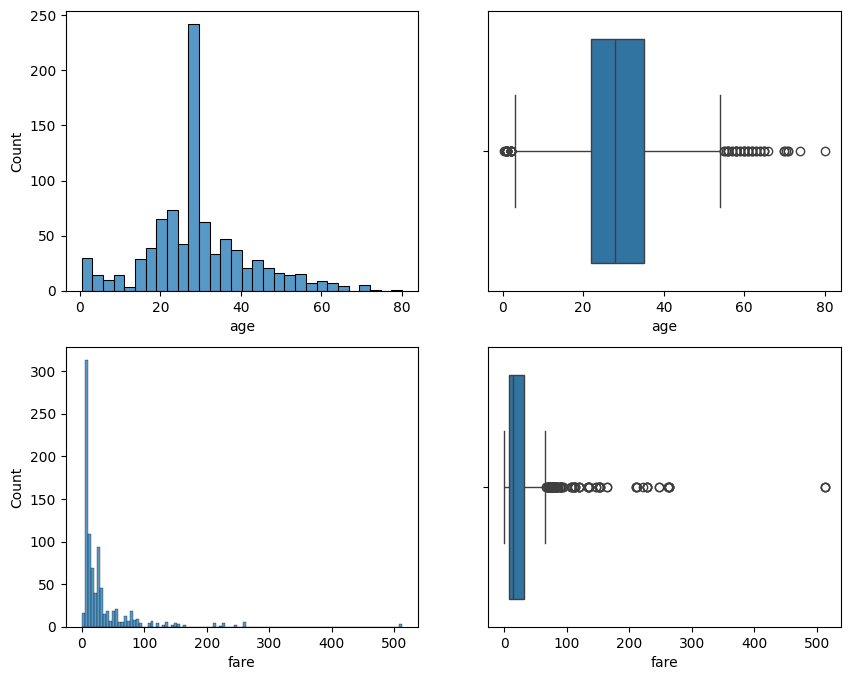

Age Outliers: 65
Fare Outliers: 114
Fare Mean: 32.10, Median: 14.45, Mode: 8.05


In [3]:
# Plots for age and fare
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sns.histplot(df['age'], ax=axes[0,0])
sns.boxplot(x=df['age'], ax=axes[0,1])
sns.histplot(df['fare'], ax=axes[1,0])
sns.boxplot(x=df['fare'], ax=axes[1,1])
plt.show()

# IQR Outliers
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

print("Age Outliers:", count_outliers(df['age']))
print("Fare Outliers:", count_outliers(df['fare']))

# Mean, Median, Mode for Fare
fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode()[0]

print(f"Fare Mean: {fare_mean:.2f}, Median: {fare_median:.2f}, Mode: {fare_mode:.2f}")

The largest absolute off-diagonal numbers usually involve pclass and fare


Survival by Sex: sex
female    0.740385
male      0.188908
Name: count, dtype: float64
Survival by Pclass: pclass
1    0.626168
2    0.472826
3    0.242363
Name: count, dtype: float64


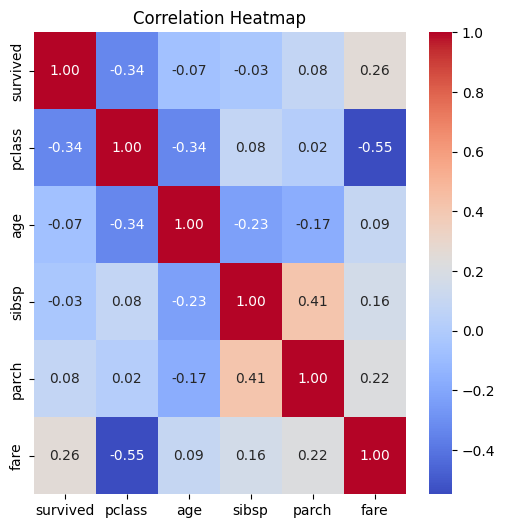

In [4]:
# Boolean masking for survival rates
print("Survival by Sex:", df[df['survived'] == 1]['sex'].value_counts() / df['sex'].value_counts())
print("Survival by Pclass:", df[df['survived'] == 1]['pclass'].value_counts() / df['pclass'].value_counts())

# Correlation Matrix
cols_for_corr = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[cols_for_corr].corr()

plt.figure(figsize=(6, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Multivariate Data Story & Standardization Check

--- Setup: Ensuring base data is ready ---
Base DataFrame shape: (889, 14)
--------------------

--- Generating Chart 1: Survival Counts by Class and Sex ---


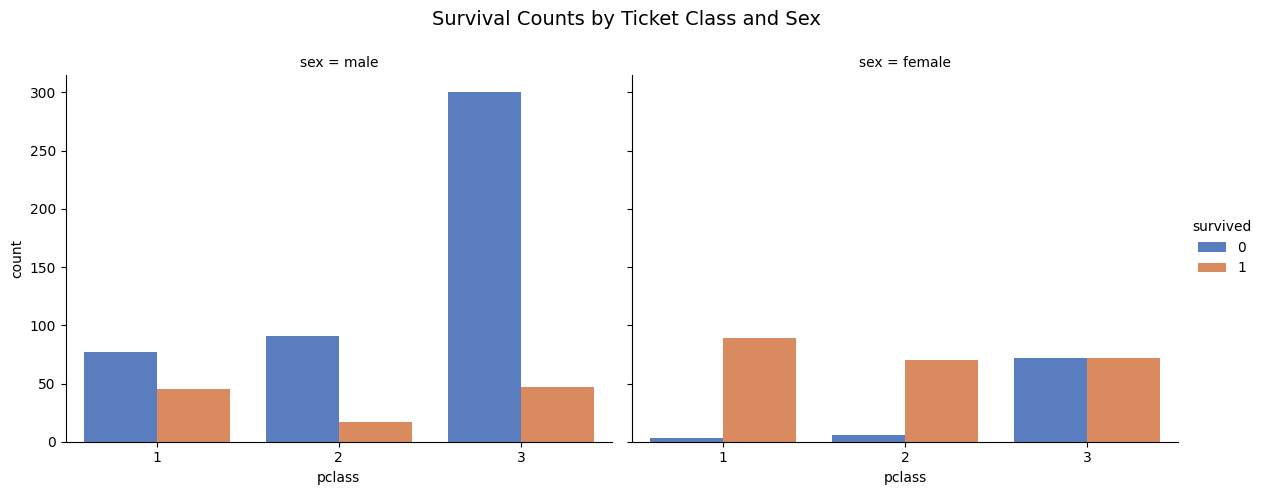


--- Generating Chart 2: Age Distribution by Sex/Survival ---


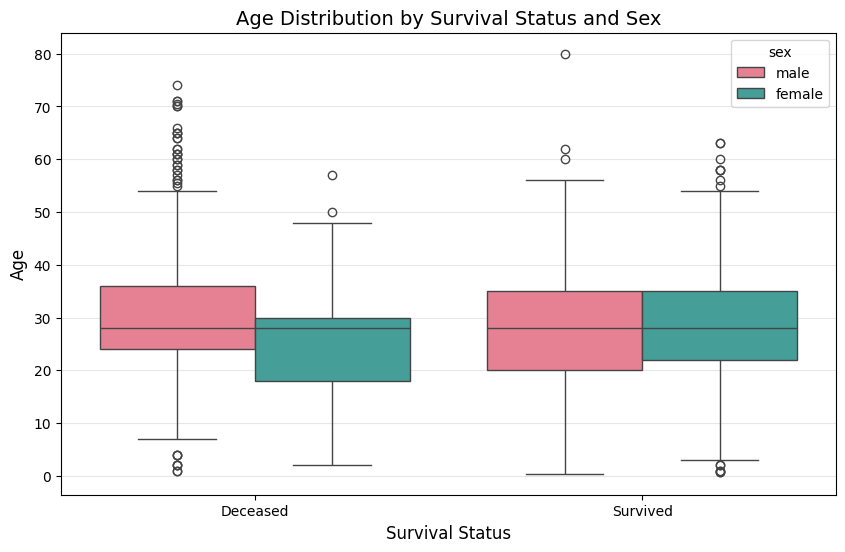


--- Generating Chart 3: Fare, Pclass, and Survival ---


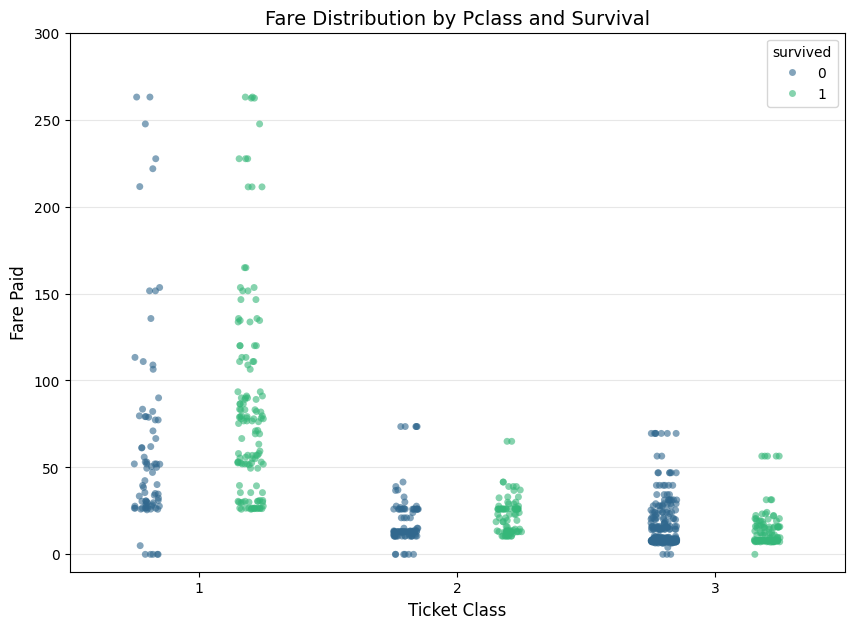


--- Generating Chart 4: Family Size, Pclass, and Survival ---


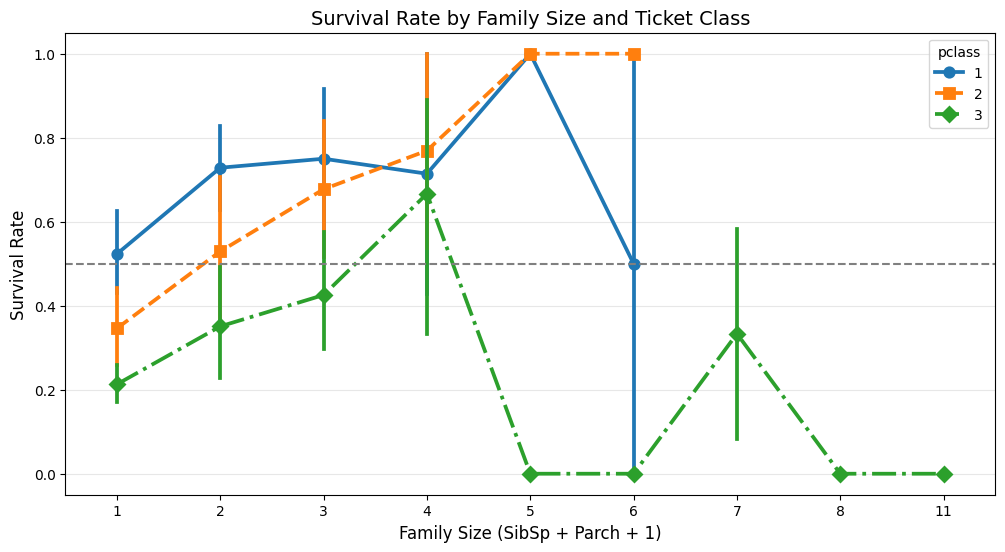


All Four Multivariate Charts Generated.
--------------------

--- Exploratory Z-Score standardization check (Task 6) ---

--- SUMMARY COMPARISON (Original vs Standardized) ---

Original Numeric Profiles (Before):
              age        fare
count  889.000000  889.000000
mean    29.315152   32.096681
std     12.984932   49.697504
min      0.420000    0.000000
25%     22.000000    7.895800
50%     28.000000   14.454200
75%     35.000000   31.000000
max     80.000000  512.329200

Standardized Numeric Profiles (After Check):
        age_z  fare_z
count  889.00  889.00
mean     0.00    0.00
std      1.00    1.00
min     -2.23   -0.65
25%     -0.56   -0.49
50%     -0.10   -0.35
75%      0.44   -0.02
max      3.90    9.66

Verification check results:
Age Z-score Mean/Std: 0.0 / 1.0
Fare Z-score Mean/Std: 0.0 / 1.0


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- REQUIRED SETUP (Assuming df is cleaned from Step 2) ---
# Ensure you have your cleaned 'df' available in this cell.
# If you are running this cell alone, run Step 1 & 2 first.
print("--- Setup: Ensuring base data is ready ---")
print(f"Base DataFrame shape: {df.shape}")
print("-" * 20)

# --- CHART 1: Survival by Ticket Class and Sex (Countplot) ---
print("\n--- Generating Chart 1: Survival Counts by Class and Sex ---")
g1 = sns.catplot(
    data=df,
    x='pclass',
    hue='survived',
    col='sex',
    kind='count',
    palette='muted',
    height=5,
    aspect=1.2
)
# Adjust title placement so it doesn't overlap labels
plt.subplots_adjust(top=0.85)
g1.fig.suptitle('Survival Counts by Ticket Class and Sex', fontsize=14)
plt.show()

# --- Placeholder for WRITTEN INTERPRETATION for Chart 1 ---
# [Write 2–4 sentences interpreting this chart in your notebook/README.
# Example: This chart reveals a profound disparity in survival based on gender across all classes.
# Females had significantly higher survival counts than males, especially in Pclass 1 and 2.
# Male casualties were overwhelmingly high in Pclass 3 compared to any other group.]

# --- CHART 2: Age Distribution by Sex and Survival Status (Boxplot) ---
print("\n--- Generating Chart 2: Age Distribution by Sex/Survival ---")
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='survived',
    y='age',
    hue='sex',
    palette='husl'
)
plt.title('Age Distribution by Survival Status and Sex', fontsize=14)
plt.xticks([0, 1], ['Deceased', 'Survived'])
plt.ylabel('Age', fontsize=12)
plt.xlabel('Survival Status', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- Placeholder for WRITTEN INTERPRETATION for Chart 2 ---
# [Write 2–4 sentences interpreting this chart in your notebook/README.
# Example: This boxplot shows that for males, survivors generally had a lower median age
# compared to the deceased, confirming that children were likely prioritized among males.
# For females, the median age for deceased and survivors is quite similar, reflecting high
# survival across most age groups.]

# --- CHART 3: Fare Distribution by Pclass and Survival Status (Stripplot) ---
print("\n--- Generating Chart 3: Fare, Pclass, and Survival ---")
plt.figure(figsize=(10, 7))
# Limiting ylim as some fares are very high outliers (>500)
# which obscure the main clusters.
sns.stripplot(
    data=df,
    x='pclass',
    y='fare',
    hue='survived',
    dodge=True,
    jitter=True,
    alpha=0.6,
    palette='viridis'
)
plt.title('Fare Distribution by Pclass and Survival', fontsize=14)
plt.ylabel('Fare Paid', fontsize=12)
plt.xlabel('Ticket Class', fontsize=12)
plt.grid(axis='y', alpha=0.3)
# We cap the visual range to see the density clearly, outliers are still in data.
plt.ylim(-10, 300)
plt.show()

# --- Placeholder for WRITTEN INTERPRETATION for Chart 3 ---
# [Write 2–4 sentences interpreting this chart in your notebook/README.
# Example: Chart 3 visualizes how ticket price (Fare) correlates strongly with Pclass and survival.
# Pclass 1 survivors (green dots) paid the highest fares. Conversely, Pclass 3 is dominated by
# low fare payers who overwhelmingly did not survive (purple dots).]

# --- CHART 4: Family Size, Pclass, and Survival Rates (Point Plot) ---
# NOTE: We need to engineer 'family_size' first for this multivariate story point.
print("\n--- Generating Chart 4: Family Size, Pclass, and Survival ---")

# Creating engineered features needed for the Data Story
# Need a copy to avoid SettingWithCopy warnings if modifying 'df' directly
df_story = df.copy()
df_story['family_size'] = df_story['sibsp'] + df_story['parch'] + 1

plt.figure(figsize=(12, 6))
sns.pointplot(
    data=df_story,
    x='family_size',
    y='survived',
    hue='pclass',
    palette='tab10',
    markers=["o", "s", "D"],
    linestyles=["-", "--", "-."]
)
plt.title('Survival Rate by Family Size and Ticket Class', fontsize=14)
plt.ylabel('Survival Rate', fontsize=12)
plt.xlabel('Family Size (SibSp + Parch + 1)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
# Add a line showing 50% survival rate for reference
plt.axhline(0.5, color='gray', linestyle='--')
plt.show()

# --- Placeholder for WRITTEN INTERPRETATION for Chart 4 ---
# [Write 2–4 sentences interpreting this chart in your notebook/README.
# Example: This point plot reveals an intersection between class, family size, and survival rates.
# In Pclass 1 and 2, moderate family sizes (2–4 members) actually correlate with the highest survival
# chances. However, in Pclass 3, survival chances drop drastically as family size exceeds 4.]

print("\nAll Four Multivariate Charts Generated.")
print("-" * 20)

# ==============================================================================
# --- Exploratory Z-Score standardization check (Requested by User) ---
# ==============================================================================
# You requested this specific check in your prompt.
# This check is an exploratory EDA step required by Task 6.
print("\n--- Exploratory Z-Score standardization check (Task 6) ---")
df_check = df.copy()

# Compute manually using Task 6 requirements formula (z = (x - mean) / std)
df_check['age_z'] = (df['age'] - df['age'].mean()) / df['age'].std()
df_check['fare_z'] = (df['fare'] - df['fare'].mean()) / df['fare'].std()

# Showing before/after summary comparison
print("\n--- SUMMARY COMPARISON (Original vs Standardized) ---")
print("\nOriginal Numeric Profiles (Before):")
print(df[['age', 'fare']].describe())

print("\nStandardized Numeric Profiles (After Check):")
# We use round(2) as required to match the output check requested.
print(df_check[['age_z', 'fare_z']].describe().round(2))

# Verify specific means are close to 0 and stds are close to 1
print("\nVerification check results:")
print(f"Age Z-score Mean/Std: {round(df_check['age_z'].mean(), 2)} / {round(df_check['age_z'].std(), 2)}")
print(f"Fare Z-score Mean/Std: {round(df_check['fare_z'].mean(), 2)} / {round(df_check['fare_z'].std(), 2)}")

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Train/Test Split
X = df.drop(columns=['survived', 'alive', 'who', 'adult_male', 'alone', 'class'], errors='ignore')
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Preprocessing
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['sex', 'embarked']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Example Pipeline with Logistic Regression
log_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

log_pipe.fit(X_train, y_train)
y_pred = log_pipe.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.7808988764044944



--- Logistic Regression Confusion Matrix ---
[[96 14]
 [25 43]]

--- Decision Tree Confusion Matrix ---
[[98 12]
 [23 45]]

--- Random Forest Confusion Matrix ---
[[97 13]
 [22 46]]


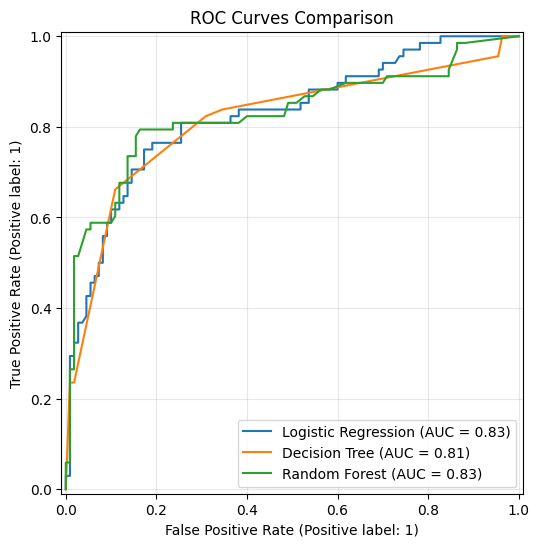


MODEL EVALUATION COMPARISON TABLE
              Model  Accuracy  Precision  Recall  F1 Score    AUC
Logistic Regression    0.7809     0.7544  0.6324    0.6880 0.8265
      Decision Tree    0.8034     0.7895  0.6618    0.7200 0.8144
      Random Forest    0.8034     0.7797  0.6765    0.7244 0.8283

--- Rendering Decision Tree Visualization ---


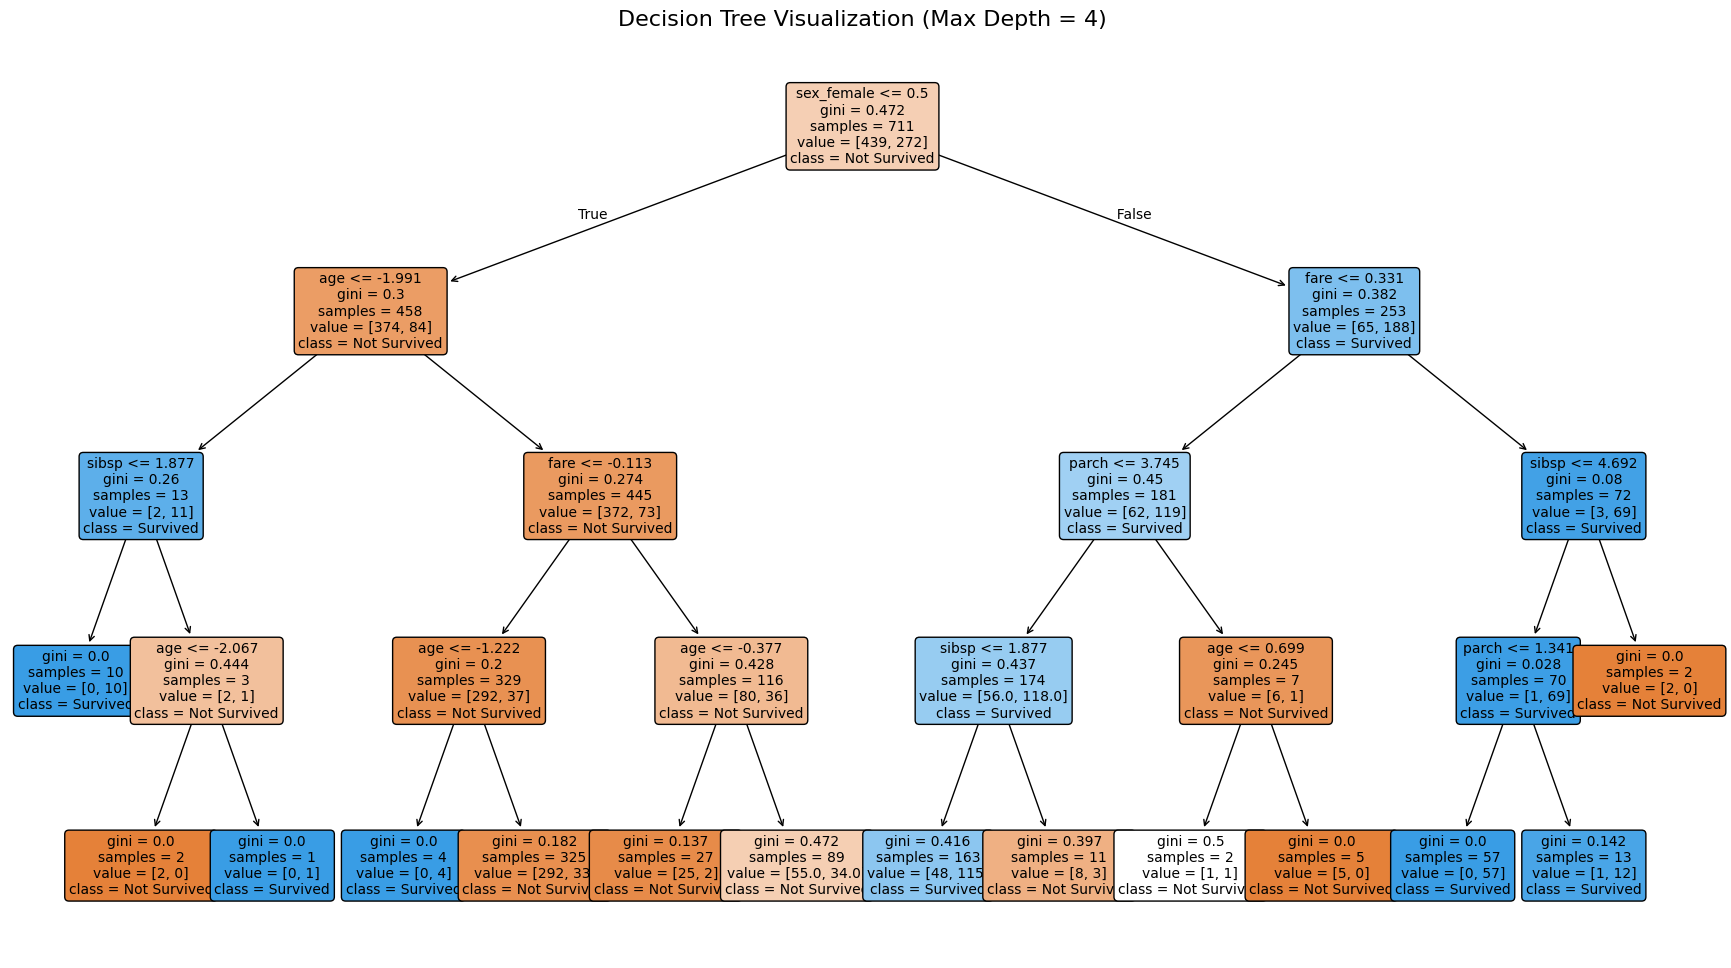

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, RocCurveDisplay)

# 1. Define the three models required by Task 9
# We set a random_state for reproducibility and limit the Decision Tree depth
# so the plot is actually readable.
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=4),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

# Dictionaries to hold our trained pipelines and their evaluation metrics
trained_pipelines = {}
metrics_summary = []

# Set up a single plot for all three ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Loop through each model to train and evaluate
for name, model in models.items():

    # Create the pipeline joining our previous preprocessor and the current model
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Fit (train) the pipeline on the training data ONLY
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    # Predict on the test data
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] # Get probabilities for AUC

    # Calculate all required metrics for Task 10
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    # Print the confusion matrix immediately
    print(f"\n--- {name} Confusion Matrix ---")
    print(cm)

    # Save the metrics to our summary list
    metrics_summary.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC": auc
    })

    # Add this model's ROC curve to our shared plot
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

# Display the ROC Curve plot
plt.title("ROC Curves Comparison")
plt.grid(alpha=0.3)
plt.show()

# 3. Present side-by-side in a single comparison table (Task 10)
print("\n" + "="*60)
print("MODEL EVALUATION COMPARISON TABLE")
print("="*60)
metrics_df = pd.DataFrame(metrics_summary)
# Formatting the numbers to 4 decimal places for readability
print(metrics_df.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))
print("="*60 + "\n")

# 4. Render the Decision Tree with plot_tree (Task 9)
print("--- Rendering Decision Tree Visualization ---")

# To plot the tree, we need to extract the actual tree model from the pipeline
dt_classifier = trained_pipelines["Decision Tree"].named_steps['classifier']

# We also need to extract the feature names created by the OneHotEncoder
# so we can label the tree branches properly
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features)
all_features = numeric_features + list(encoded_cat_features)

# Plotting the tree
plt.figure(figsize=(22, 12))
plot_tree(
    dt_classifier,
    feature_names=all_features,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization (Max Depth = 4)", fontsize=16)
plt.show()

In [8]:
import joblib

# Save the full pipeline object to disk
joblib.dump(log_pipe, 'titanic_pipeline.joblib')

# Test reloading it
loaded_model = joblib.load('titanic_pipeline.joblib')
print("Reload test accuracy:", accuracy_score(y_test, loaded_model.predict(X_test)))

Reload test accuracy: 0.7808988764044944
